# SDSS vs Legacy: local FITS and JPEG comparison

This notebook picks one random target from your local `manga_sdss_fits` directory and compares SDSS vs Legacy cutouts for the same `plateifu`.

- SDSS FITS/JPEG: loaded from `sdss_cutouts`
- Legacy FITS/JPEG: loaded from `legacy_cutouts`

Use this to verify that your local FITS data and JPEG representations line up for the same object.

In [112]:
# If needed, uncomment and run:
# %pip install astropy matplotlib pillow reproject

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

In [113]:
data_root = Path("manga_sdss_fits")
if not data_root.exists():
    raise FileNotFoundError("Could not find 'manga_sdss_fits' in the current working directory.")

plateifu_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
if not plateifu_dirs:
    raise RuntimeError("No target directories found inside manga_sdss_fits.")

target_dir = random.choice(plateifu_dirs)
plateifu = target_dir.name

sdss_dir = target_dir / "sdss_cutouts"
legacy_dir = target_dir / "legacy_cutouts"

if not sdss_dir.exists() or not legacy_dir.exists():
    raise RuntimeError(f"Missing sdss_cutouts/legacy_cutouts for {plateifu}.")

sdss_meta_path = sdss_dir / "metadata.json"
legacy_meta_path = legacy_dir / "metadata.json"

if not sdss_meta_path.exists() or not legacy_meta_path.exists():
    raise RuntimeError(f"Missing metadata.json files for {plateifu}.")

sdss_meta = json.loads(sdss_meta_path.read_text())
legacy_meta = json.loads(legacy_meta_path.read_text())

ra = float(sdss_meta["ra_deg"])
dec = float(sdss_meta["dec_deg"])

print(f"Selected plateifu: {plateifu}")
print(f"RA, Dec = {ra:.6f}, {dec:.6f}")

Selected plateifu: 11952_6103
RA, Dec = 253.959603, 27.441578


In [114]:
def load_fits_data_and_wcs(path):
    with fits.open(path) as hdul:
        data = hdul[0].data.astype(float)
        wcs = WCS(hdul[0].header)
    return data, wcs


def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def pick_jpeg_path(cutout_dir, prefix):
    # Prefer explicit metadata filename if available.
    meta_path = cutout_dir / "metadata.json"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        jpeg_name = meta.get("jpeg_file")
        if jpeg_name:
            p = cutout_dir / jpeg_name
            if p.exists():
                return p

    # Fallback: first matching JPEG in folder.
    for p in sorted(cutout_dir.glob(f"{prefix}-*-color.jpg")):
        return p
    return None


plateifu_hyphen = plateifu.replace("_", "-")

# Use r-band FITS for direct SDSS/Legacy grayscale comparison.
sdss_r_path = first_existing([
    sdss_dir / f"sdss-{plateifu}-r.fits",
    sdss_dir / f"sdss-{plateifu_hyphen}-r.fits",
])
legacy_r_path = first_existing([
    legacy_dir / f"legacy-{plateifu}-r.fits",
    legacy_dir / f"legacy-{plateifu_hyphen}-r.fits",
])

sdss_jpeg_path = pick_jpeg_path(sdss_dir, "sdss")
legacy_jpeg_path = pick_jpeg_path(legacy_dir, "legacy")

required_paths = [sdss_r_path, legacy_r_path, sdss_jpeg_path, legacy_jpeg_path]
if any(p is None for p in required_paths):
    debug_files = {
        "sdss_cutouts": [p.name for p in sorted(sdss_dir.glob("*"))],
        "legacy_cutouts": [p.name for p in sorted(legacy_dir.glob("*"))],
    }
    raise FileNotFoundError(
        "Could not resolve expected SDSS/Legacy r-band FITS or color JPEG files.\n"
        f"plateifu folder: {plateifu}\n"
        f"Available files: {json.dumps(debug_files, indent=2)}"
    )

sdss_data, sdss_wcs = load_fits_data_and_wcs(sdss_r_path)
legacy_data, legacy_wcs = load_fits_data_and_wcs(legacy_r_path)

# Reproject SDSS FITS onto the Legacy FITS WCS grid to fix orientation/parity mismatch.
sdss_data_display, _ = reproject_interp(
    (sdss_data, sdss_wcs),
    legacy_wcs,
    shape_out=legacy_data.shape,
)

sdss_jpeg = np.array(Image.open(sdss_jpeg_path).convert("RGB"))
legacy_jpeg = np.array(Image.open(legacy_jpeg_path).convert("RGB"))

print("SDSS r FITS:", sdss_r_path)
print("Legacy r FITS:", legacy_r_path)
print("SDSS JPEG:", sdss_jpeg_path)
print("Legacy JPEG:", legacy_jpeg_path)

print("\nSDSS FITS shape:", sdss_data.shape)
print("Legacy FITS shape:", legacy_data.shape)
print("SDSS JPEG shape:", sdss_jpeg.shape)
print("Legacy JPEG shape:", legacy_jpeg.shape)

if "scale_arcsec_per_px" in sdss_meta:
    print(f"SDSS metadata scale: {sdss_meta['scale_arcsec_per_px']} arcsec/pixel")
if "size_px" in sdss_meta:
    print(f"SDSS metadata size:  {sdss_meta['size_px']} px")
if "size_px" in legacy_meta:
    print(f"Legacy metadata size: {legacy_meta['size_px']} px")

SDSS r FITS: manga_sdss_fits\11952_6103\sdss_cutouts\sdss-11952-6103-r.fits
Legacy r FITS: manga_sdss_fits\11952_6103\legacy_cutouts\legacy-11952-6103-r.fits
SDSS JPEG: manga_sdss_fits\11952_6103\sdss_cutouts\sdss-11952-6103-color.jpg
Legacy JPEG: manga_sdss_fits\11952_6103\legacy_cutouts\legacy-11952-6103-color.jpg

SDSS FITS shape: (196, 196)
Legacy FITS shape: (198, 198)
SDSS JPEG shape: (196, 196, 3)
Legacy JPEG shape: (198, 198, 3)
SDSS metadata scale: 0.198 arcsec/pixel
SDSS metadata size:  196 px
Legacy metadata size: 198 px


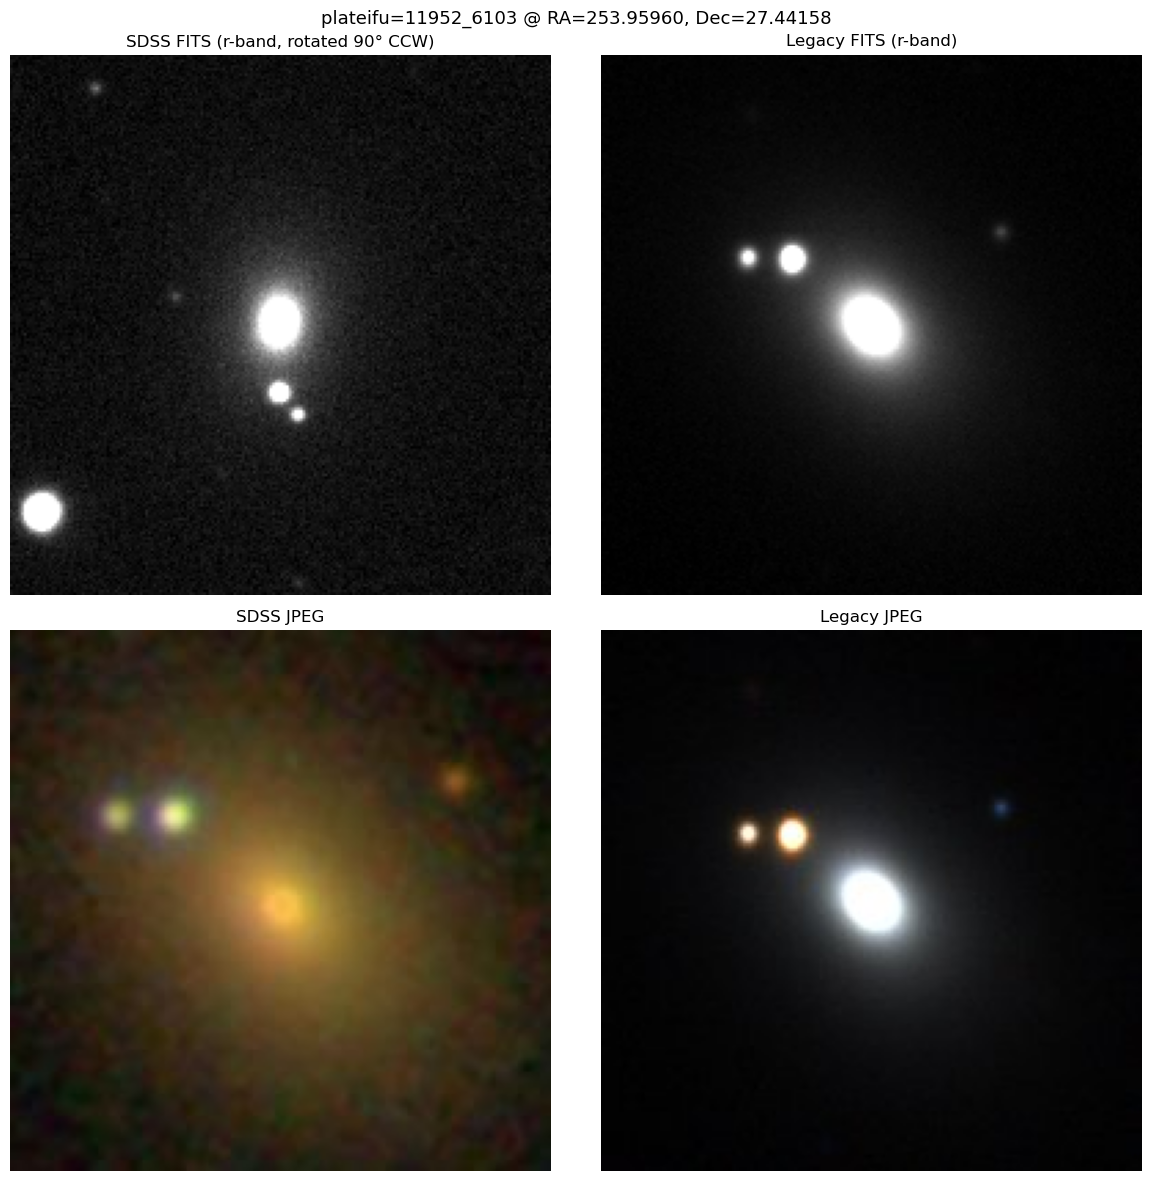

In [115]:
def robust_limits(data, lo=1, hi=99):
    vals = data[np.isfinite(data)]
    if vals.size == 0:
        return 0, 1
    return np.percentile(vals, [lo, hi])


sdss_vmin, sdss_vmax = robust_limits(sdss_data_display)
legacy_vmin, legacy_vmax = robust_limits(legacy_data)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(sdss_data_display, origin="lower", cmap="gray", vmin=sdss_vmin, vmax=sdss_vmax)
axes[0, 0].set_title("SDSS FITS (r-band, reprojected to Legacy WCS)")
axes[0, 0].axis("off")

axes[0, 1].imshow(legacy_data, origin="lower", cmap="gray", vmin=legacy_vmin, vmax=legacy_vmax)
axes[0, 1].set_title("Legacy FITS (r-band)")
axes[0, 1].axis("off")

axes[1, 0].imshow(sdss_jpeg)
axes[1, 0].set_title("SDSS JPEG")
axes[1, 0].axis("off")

axes[1, 1].imshow(legacy_jpeg)
axes[1, 1].set_title("Legacy JPEG")
axes[1, 1].axis("off")

fig.suptitle(f"plateifu={plateifu} @ RA={ra:.5f}, Dec={dec:.5f}", fontsize=13)
plt.tight_layout()
plt.show()

In [116]:
# Optional: quick sanity checks about pixel scales from WCS
from astropy.wcs.utils import proj_plane_pixel_scales

sdss_scale_measured = proj_plane_pixel_scales(sdss_wcs)[0] * 3600
legacy_scale_measured = proj_plane_pixel_scales(legacy_wcs)[0] * 3600

print(f"Measured SDSS cutout scale:  {sdss_scale_measured:.4f} arcsec/pixel")
print(f"Measured Legacy cutout scale:{legacy_scale_measured:.4f} arcsec/pixel")

Measured SDSS cutout scale:  0.3960 arcsec/pixel
Measured Legacy cutout scale:0.2620 arcsec/pixel
